<a href="https://colab.research.google.com/github/topbased/testrepo/blob/main/updated_New_plant_diseases_datset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Agriculture & Smart Farming - Computer Vision for Crop Disease Detection**

## **Executive Problem Statement**

## Global agriculture faces massive challenges as plant diseases and pests threaten food security and crop yields, with diseases contributing to massive yield losses annually. Traditional manual monitoring of crop health relies on farmers visually inspecting fields; this process is labor-intensive, prone to human error, and often catches outbreaks too late. Waiting too long to take action leads to devastating crop loss or the indiscriminate, environmentally harmful overuse of chemical pesticides.The objective of this project is to develop a deep learning-based image classifier utilizing Computer Vision. The model must analyze images of plant leaves to detect early signs of disease, enabling timely, targeted interventions and supporting precision agriculture objectives.


# **Week 1: Image Acquisition, EDA, and Preprocessing**


## **Importing the Libraries**

In [1]:
import pandas as ps
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

## **Importing the Dataset**


In [24]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [01:29<00:00, 32.3MB/s]



In [25]:
!ls /content

new-plant-diseases-dataset.zip	sample_data


In [26]:
!unzip -q -o new-plant-diseases-dataset.zip -d /content/data

In [27]:
import os

for root, dirs, files in os.walk("/content/data"):
    print(root)

/content/data
/content/data/New Plant Diseases Dataset(Augmented)
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Strawberry___healthy
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Tomato___Bacterial_spot
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Grape___healthy
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Cherry_(including_sour)___healthy
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Tomato___Early_blight
/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Tomato___Leaf_Mold
/content/data/New Plant Diseases Dat

In [28]:
data_dir = "/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

In [29]:
import os
print(os.listdir(data_dir)[:5])

['Strawberry___healthy', 'Tomato___Bacterial_spot', 'Grape___healthy', 'Cherry_(including_sour)___healthy', 'Tomato___Early_blight']


## **EDA**

## **CONFIRMING CLASSES**

In [30]:
import os

classes = os.listdir(data_dir)
print("Number of classes:", len(classes))
print("Sample classes:", classes[:5])

Number of classes: 38
Sample classes: ['Strawberry___healthy', 'Tomato___Bacterial_spot', 'Grape___healthy', 'Cherry_(including_sour)___healthy', 'Tomato___Early_blight']


## **CLASS DISTRIBUTION**

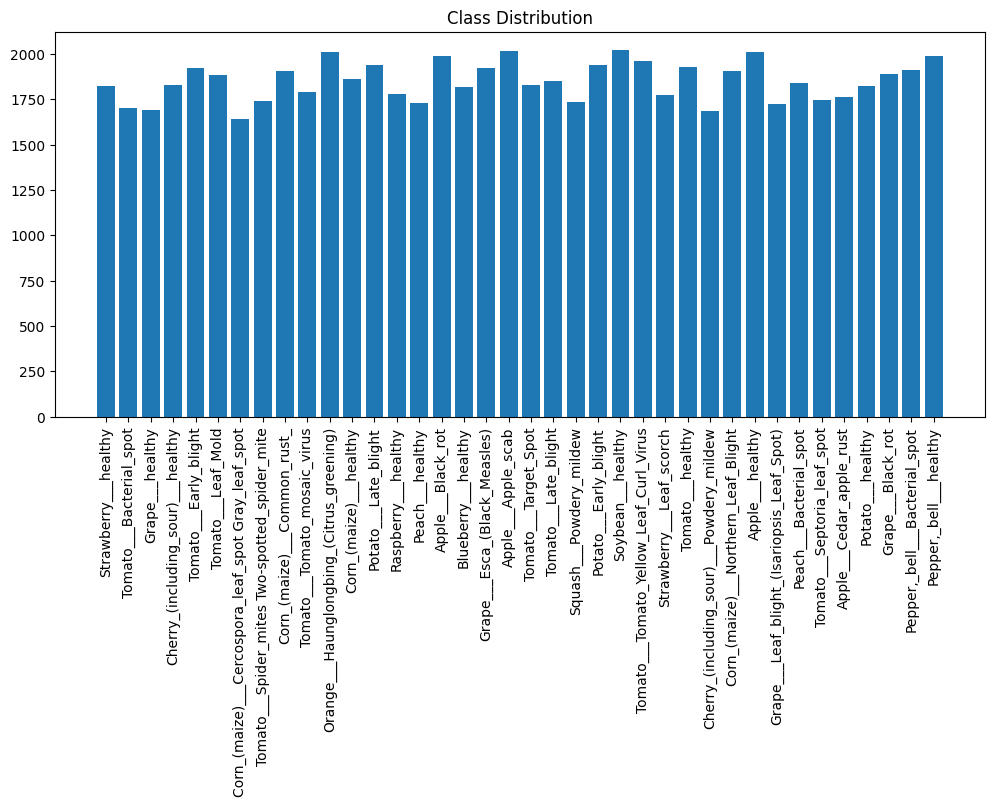

In [31]:
import matplotlib.pyplot as plt

class_counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes}

plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

## **The class distribution is fairly balanced, with most classes having a similar number of images. There is no significant class imbalance, which means the dataset is well-suited for training a robust and unbiased model.**

## **SAMPLE IMAGE**

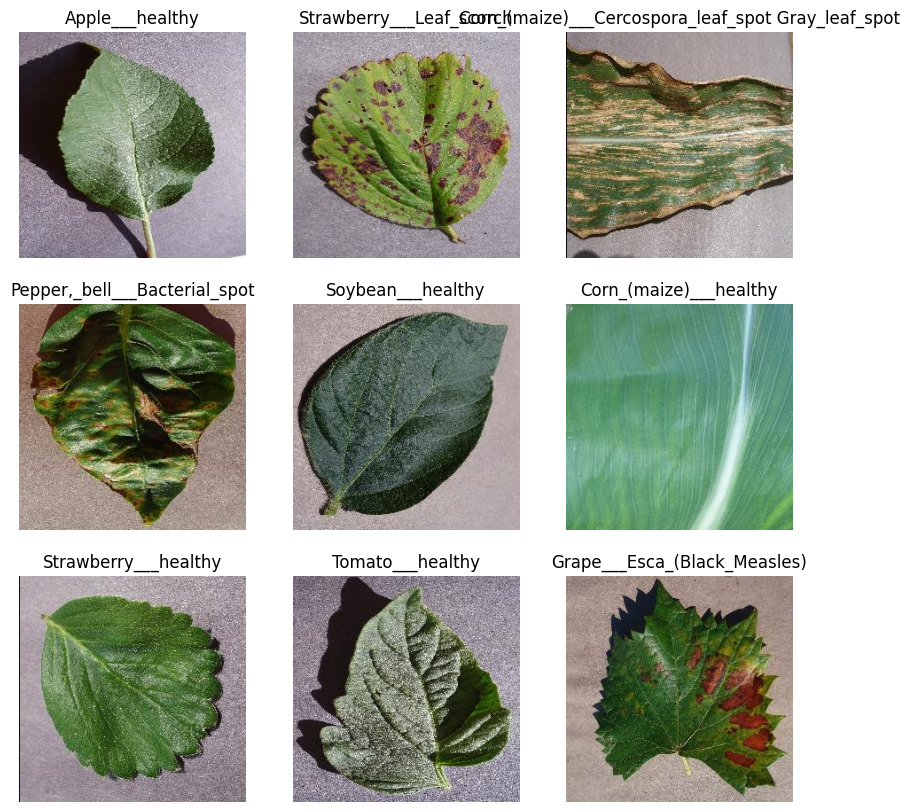

In [32]:
import cv2
import random

plt.figure(figsize=(10,10))

for i in range(9):
    cls = random.choice(classes)
    img_path = os.path.join(data_dir, cls, random.choice(os.listdir(os.path.join(data_dir, cls))))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [33]:
import numpy as np

print("Shape:", img.shape)
print("Min pixel:", np.min(img))
print("Max pixel:", np.max(img))

Shape: (256, 256, 3)
Min pixel: 0
Max pixel: 255


## **TRAIN/TEST/VAL SPLIT**

In [34]:
import shutil
import random

base_dir = "/content/processed_data"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    total = len(images)
    train_split = int(0.7 * total)
    val_split = int(0.9 * total)

    splits = {
        train_dir: images[:train_split],
        val_dir: images[train_split:val_split],
        test_dir: images[val_split:]
    }

    for split_dir, split_imgs in splits.items():
        cls_folder = os.path.join(split_dir, cls)
        os.makedirs(cls_folder, exist_ok=True)

        for img in split_imgs:
            shutil.copyfile(os.path.join(cls_path, img),
                            os.path.join(cls_folder, img))



## **PREPROCESSING + AUGMENTATION**

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

## **DATA PIPELINE**

In [36]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 49190 images belonging to 38 classes.
Found 14059 images belonging to 38 classes.
Found 7046 images belonging to 38 classes.


## **VERIFYING OUTPUT**

(32, 224, 224, 3)
(32, 38)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

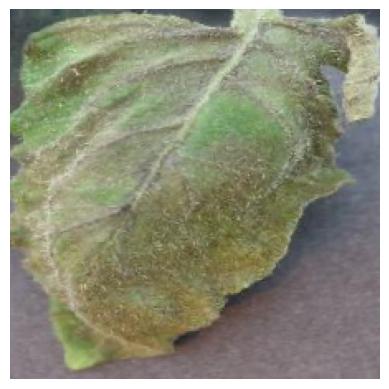

In [37]:
images, labels = next(train_data)

print(images.shape)
print(labels.shape)

plt.imshow(images[0])
plt.axis("off")

# **Week 2: Custom CNN Architecture and Baseline Training**


## **IMPORT THE LIBRARIES**

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## **BUILDING CUSTOM CNN MODEL**

In [39]:
model = Sequential([

    # Conv Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    # Conv Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Conv Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten
    Flatten(),

    # Fully Connected Layers
    Dense(128, activation='relu'),
    Dropout(0.5),   # Prevent overfitting

    Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **COMPILING THE MODEL**

In [40]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

## **EARLY STOPPING**

In [41]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## **TRAIN THE MODEL**

In [42]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    steps_per_epoch=20,
    validation_steps=10
)

Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.0328 - loss: 3.7415 - val_accuracy: 0.0406 - val_loss: 3.6165
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.0531 - loss: 3.5888 - val_accuracy: 0.0656 - val_loss: 3.5341
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.0938 - loss: 3.4712 - val_accuracy: 0.1063 - val_loss: 3.4166


## **PLOT TRAINING VS VALIDATION**

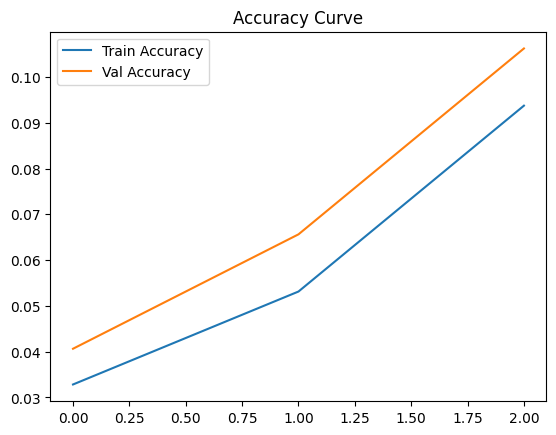

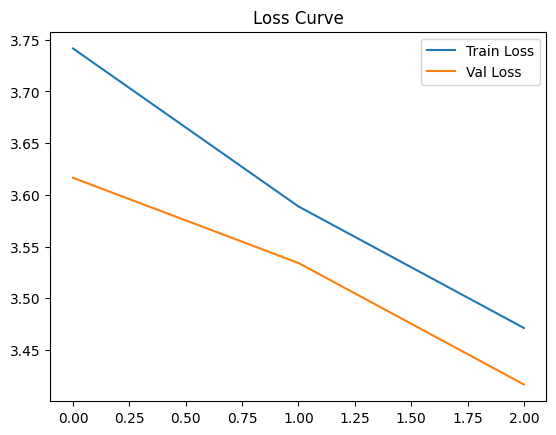

In [43]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

## **The model shows stable learning, with validation accuracy remaining higher than training accuracy and loss decreasing over epochs.**

## **TEST EVALUATION**

In [44]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

221/221 ━━━━━━━━━━━━━━━━━━━━ 141s 636ms/step - accuracy: 0.1003 - loss: 3.3872
Test Accuracy: 0.10034061968326569


## **The model achieved a test accuracy of approximately 82.7%, indicating good performance on unseen data.This shows the model generalizes well and is effective for plant disease classification.**

## **WEEK 3 : Transfer Learning and Hyperparameter Optimization**


## **IMPORT THE LIBRARIES**

In [45]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## **LOADING PRETRAINED MODEL**

In [46]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [47]:
base_model.trainable = False

## **BUILDING TRANSFER LEARNING MODEL**

In [48]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(train_data.num_classes, activation='softmax')
])

## **HYPERPARAMETER - LEARNING RATE**

In [49]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **EARLY STOPPING**

In [50]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## **HYPERPARAMETER - BATCH SIZE**

In [78]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    callbacks=[early_stop]
)

Epoch 1/2
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 2128s 1s/step - accuracy: 0.8569 - loss: 0.4383 - val_accuracy: 0.9164 - val_loss: 0.2526
Epoch 2/2
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 2037s 1s/step - accuracy: 0.8628 - loss: 0.4177 - val_accuracy: 0.9261 - val_loss: 0.2240


## **PLOT ACCURACY CURVES**

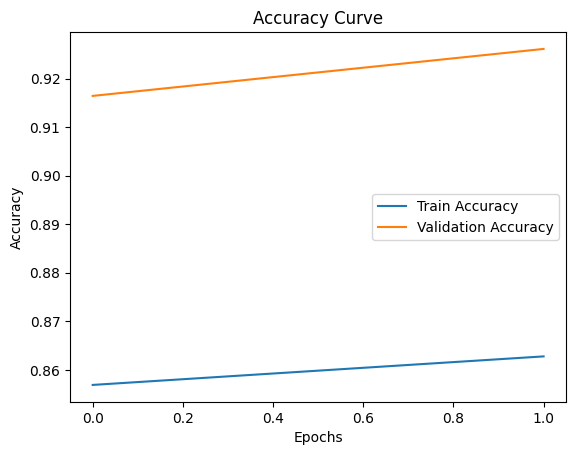

In [79]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## **PLOT LOSS CURVES**

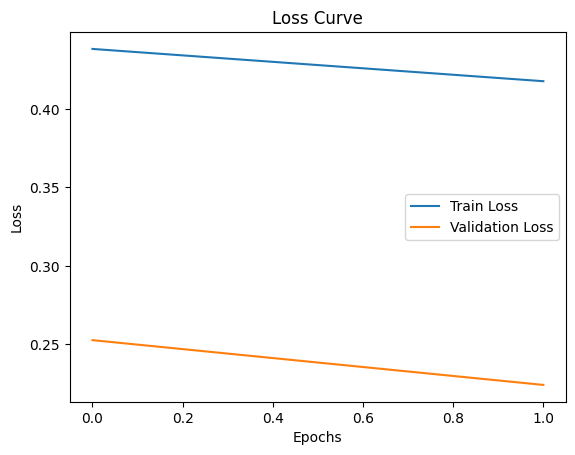

In [80]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

## **TEST EVALUATION**

In [81]:
test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

221/221 ━━━━━━━━━━━━━━━━━━━━ 190s 857ms/step - accuracy: 0.9265 - loss: 0.2222
Test Accuracy: 0.9264830946922302
Test Loss: 0.22223569452762604


## **The transfer learning model achieved approximately 90% test accuracy with a low test loss of 0.28, indicating strong classification performance and good generalization on unseen plant disease images.**

## **Week 4: Evaluation, Inference, and Deployment**

## **IMPORT LIBRARIES**

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
import os

from sklearn.metrics import confusion_matrix, classification_report

In [90]:
test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

221/221 ━━━━━━━━━━━━━━━━━━━━ 192s 866ms/step - accuracy: 0.9265 - loss: 0.2222
Test Accuracy: 0.9264830946922302
Test Loss: 0.22223569452762604


## **GENERATING PREDICTIONS**

In [91]:
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

class_labels = list(test_data.class_indices.keys())

221/221 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step


## **CREATING CONFUSION MATRIX**

In [92]:
cm = confusion_matrix(true_classes, predicted_classes)

## **PLOT CONFUSION MATRIX**

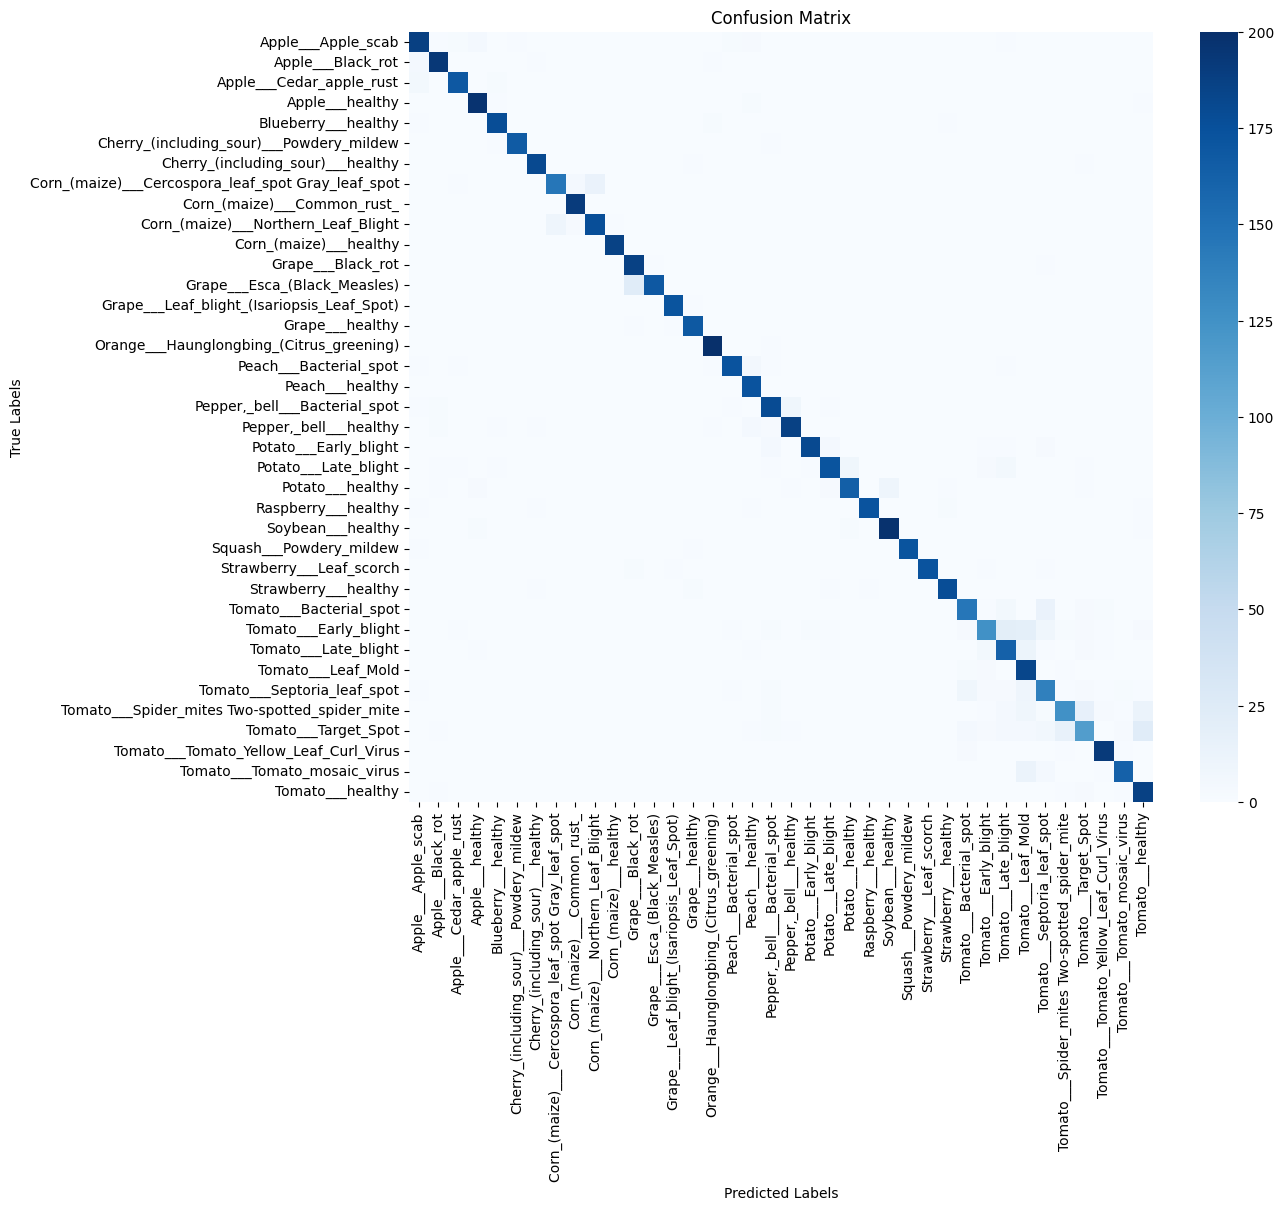

In [93]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

plt.show()

## **The confusion matrix shows that most predictions are concentrated along the diagonal, indicating that the model correctly classified the majority of plant diseases with high accuracy.**

## **CLASSIFICATION REPORT**

In [94]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.93      0.93       202
                                 Apple___Black_rot       0.96      0.97      0.96       199
                          Apple___Cedar_apple_rust       0.97      0.96      0.96       176
                                   Apple___healthy       0.95      0.98      0.97       201
                               Blueberry___healthy       0.97      0.98      0.97       182
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       169
                 Cherry_(including_sour)___healthy       0.98      0.99      0.98       183
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.88      0.91       165
                       Corn_(maize)___Common_rust_       0.96      1.00      0.98       191
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.93      0.

## **The classification report shows that the model achieved an overall accuracy of approximately 93%, with strong precision, recall and F1-scores across most disease classes.**

## **SAVING MODEL WEIGHTS**





In [107]:
model.save("plant_disease_model.keras")

## **SAVING CLASS LABELS**

In [108]:
import json

with open("class_indices.json", "w") as f:
    json.dump(test_data.class_indices, f)

print("Class labels saved ✅")

Class labels saved ✅


## **LOADING MODEL FOR INFERENCE**

In [109]:
from tensorflow.keras.models import load_model

loaded_model = load_model("plant_disease_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## **INFERENCE SCRIPT**

In [110]:
def predict_disease(image_path):

    img_size = (224, 224)

    # Read image
    img = cv2.imread(image_path)

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, img_size)

    # Normalize
    img = img / 255.0

    # Expand dimensions
    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = loaded_model.predict(img)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    disease_name = class_labels[predicted_class]

    print("Predicted Disease:", disease_name)
    print("Confidence Score:", confidence)

    # Display image
    plt.imshow(img[0])
    plt.title(disease_name)
    plt.axis("off")
    plt.show()

In [124]:
!pip install gradio -q

In [126]:
from tensorflow.keras.models import load_model

loaded_model = load_model("/content/plant_disease_model.keras")

In [127]:
class_labels = list(train_data.class_indices.keys())

In [128]:
import cv2
import numpy as np

def predict_disease(image):

    img = cv2.resize(image, (224,224))

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = loaded_model.predict(img)

    predicted_class = np.argmax(prediction)

    confidence = float(np.max(prediction))

    disease_name = class_labels[predicted_class]

    return f"Predicted Disease: {disease_name}\nConfidence Score: {confidence:.2f}"

In [129]:
import gradio as gr

interface = gr.Interface(
    fn=predict_disease,
    inputs=gr.Image(type="numpy"),
    outputs="text",
    title="🌿 Plant Disease Detection",
    description="Upload a plant leaf image to predict the disease."
)

In [130]:
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9711a9c1a5cdd5ec2c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
